# LeetCode #304: Range Sum Query 2D - Immutable

https://leetcode.com/problems/range-sum-query-2d-immutable/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | O(m·n) build, O(m·n) per query | O(1) extra |
| **2D Prefix Sum** | O(m·n) build, O(1) per query | O(m·n) |

---

## Understanding the Methods

### Brute Force
Iterate over every cell in the queried rectangle and sum them on each call. Each `sumRegion` costs up to O(m·n), making repeated queries prohibitive.

### Optimal: 2D Prefix Sum ★
Precompute a (m+1)×(n+1) table where `prefix[i][j]` = sum of the submatrix from (0,0) to (i-1, j-1). Any rectangle query reduces to four table lookups via inclusion-exclusion: `prefix[r2+1][c2+1] - prefix[r1][c2+1] - prefix[r2+1][c1] + prefix[r1][c1]`.

**Why this is better than Brute Force:** The one-time O(m·n) build lets every subsequent query answer in O(1) regardless of rectangle size — instead of re-scanning the same cells on every call.

**Constraints:**
* m == matrix.length, n == matrix[i].length
* 1 ≤ m, n ≤ 200
* -10⁴ ≤ matrix[i][j] ≤ 10⁴
* 0 ≤ row1 ≤ row2 < m, 0 ≤ col1 ≤ col2 < n
* At most 10⁴ calls to sumRegion

## Solutions
### C#

In [ ]:
public class NumMatrix {
    private int[][] prefix;

    public NumMatrix(int[][] matrix) {
        int m = matrix.Length, n = matrix[0].Length;
        // Build (m+1)×(n+1) so border rows/cols stay zero — no bounds checks in query
        prefix = new int[m + 1][];
        for (int i = 0; i <= m; i++) prefix[i] = new int[n + 1];
        for (int i = 1; i <= m; i++)
            for (int j = 1; j <= n; j++)
                // Inclusion-exclusion: add top and left, subtract the corner counted twice
                prefix[i][j] = matrix[i-1][j-1] + prefix[i-1][j] + prefix[i][j-1] - prefix[i-1][j-1];
    }

    public int SumRegion(int row1, int col1, int row2, int col2) {
        // Reverse inclusion-exclusion: subtract two over-counted edges, add back the corner
        return prefix[row2+1][col2+1] - prefix[row1][col2+1] - prefix[row2+1][col1] + prefix[row1][col1];
    }
}

### Python

In [ ]:
from typing import List

class NumMatrix:
    def __init__(self, matrix: List[List[int]]):
        m, n = len(matrix), len(matrix[0])
        # Build (m+1)×(n+1) so border rows/cols stay zero — no bounds checks in query
        self.prefix = [[0] * (n + 1) for _ in range(m + 1)]
        for i in range(1, m + 1):
            for j in range(1, n + 1):
                # Inclusion-exclusion: add top and left, subtract the corner counted twice
                self.prefix[i][j] = (matrix[i-1][j-1] + self.prefix[i-1][j]
                                     + self.prefix[i][j-1] - self.prefix[i-1][j-1])

    def sumRegion(self, row1: int, col1: int, row2: int, col2: int) -> int:
        p = self.prefix
        # Reverse inclusion-exclusion: subtract two over-counted edges, add back the corner
        return p[row2+1][col2+1] - p[row1][col2+1] - p[row2+1][col1] + p[row1][col1]

### Go

In [ ]:
package main

type NumMatrix struct {
	prefix [][]int
}

func Constructor(matrix [][]int) NumMatrix {
	m, n := len(matrix), len(matrix[0])
	// Build (m+1)×(n+1) so border rows/cols stay zero — no bounds checks in query
	prefix := make([][]int, m+1)
	for i := range prefix {
		prefix[i] = make([]int, n+1)
	}
	for i := 1; i <= m; i++ {
		for j := 1; j <= n; j++ {
			// Inclusion-exclusion: add top and left, subtract the corner counted twice
			prefix[i][j] = matrix[i-1][j-1] + prefix[i-1][j] + prefix[i][j-1] - prefix[i-1][j-1]
		}
	}
	return NumMatrix{prefix}
}

func (nm *NumMatrix) SumRegion(row1, col1, row2, col2 int) int {
	p := nm.prefix
	// Reverse inclusion-exclusion: subtract two over-counted edges, add back the corner
	return p[row2+1][col2+1] - p[row1][col2+1] - p[row2+1][col1] + p[row1][col1]
}

### Rust

In [ ]:
struct NumMatrix {
    prefix: Vec<Vec<i32>>,
}

impl NumMatrix {
    fn new(matrix: Vec<Vec<i32>>) -> Self {
        let m = matrix.len();
        let n = matrix[0].len();
        // Build (m+1)×(n+1) so border rows/cols stay zero — no bounds checks in query
        let mut prefix = vec![vec![0i32; n + 1]; m + 1];
        for i in 1..=m {
            for j in 1..=n {
                // Inclusion-exclusion: add top and left, subtract the corner counted twice
                prefix[i][j] = matrix[i-1][j-1] + prefix[i-1][j] + prefix[i][j-1] - prefix[i-1][j-1];
            }
        }
        NumMatrix { prefix }
    }

    fn sum_region(&self, row1: i32, col1: i32, row2: i32, col2: i32) -> i32 {
        let (r1, c1, r2, c2) = (row1 as usize, col1 as usize, row2 as usize, col2 as usize);
        // Reverse inclusion-exclusion: subtract two over-counted edges, add back the corner
        self.prefix[r2+1][c2+1] - self.prefix[r1][c2+1] - self.prefix[r2+1][c1] + self.prefix[r1][c1]
    }
}

## Example Scenarios

**Matrix used for examples 1–3:**

```
matrix = [[1, 2, 3],
          [4, 5, 6],
          [7, 8, 9]]
```

Prefix table (1-indexed, 4×4):
```
P = [[ 0,  0,  0,  0],
     [ 0,  1,  3,  6],
     [ 0,  5, 12, 21],
     [ 0, 12, 27, 45]]
```

---

**1. Common Case — sumRegion(0, 0, 1, 1)**

**Input:** row1=0, col1=0, row2=1, col2=1 → top-left 2×2 block.

$P[2][2] - P[0][2] - P[2][0] + P[0][0] = 12 - 0 - 0 + 0 = 12$.
Verifiable: $1+2+4+5 = 12$.

---

**2. Slightly Complex — sumRegion(1, 1, 2, 2)**

**Input:** row1=1, col1=1, row2=2, col2=2 → bottom-right 2×2 block (all four prefix terms nonzero).

$P[3][3] - P[1][3] - P[3][1] + P[1][1] = 45 - 6 - 12 + 1 = 28$.
Verifiable: $5+6+8+9 = 28$.

---

**3. Edge Case: Time Factor — sumRegion(0, 0, m−1, n−1) (entire matrix)**

**Input:** row1=0, col1=0, row2=2, col2=2 — the widest possible query.

$P[3][3] - P[0][3] - P[3][0] + P[0][0] = 45 - 0 - 0 + 0 = 45$.
A Brute Force scan visits all $m \cdot n$ cells; 2D Prefix Sum answers in $O(1)$ regardless of rectangle size.

---

**4. Edge Case: Space Factor — 200×200 matrix**

**Input:** Maximum constraint: $m = n = 200$.

The prefix table is $(201 \times 201) = 40{,}401$ integers $\approx$ 158 KB (int32). Each of the $\leq 10^4$ `sumRegion` calls costs 3 additions and 1 lookup — the space trade-off eliminates $O(m \cdot n)$ work per query. Brute Force would spend up to $4 \times 10^8$ operations total.

---

**5. Almost-Impossible but Plausible — single-cell query sumRegion(r, c, r, c)**

**Input:** row1=row2=1, col1=col2=1 → query for a single element.

$P[2][2] - P[1][2] - P[2][1] + P[1][1] = 12 - 3 - 5 + 1 = 5 = \text{matrix}[1][1]$.
The four-term formula collapses to a single matrix value — no special case needed.

## Infographic

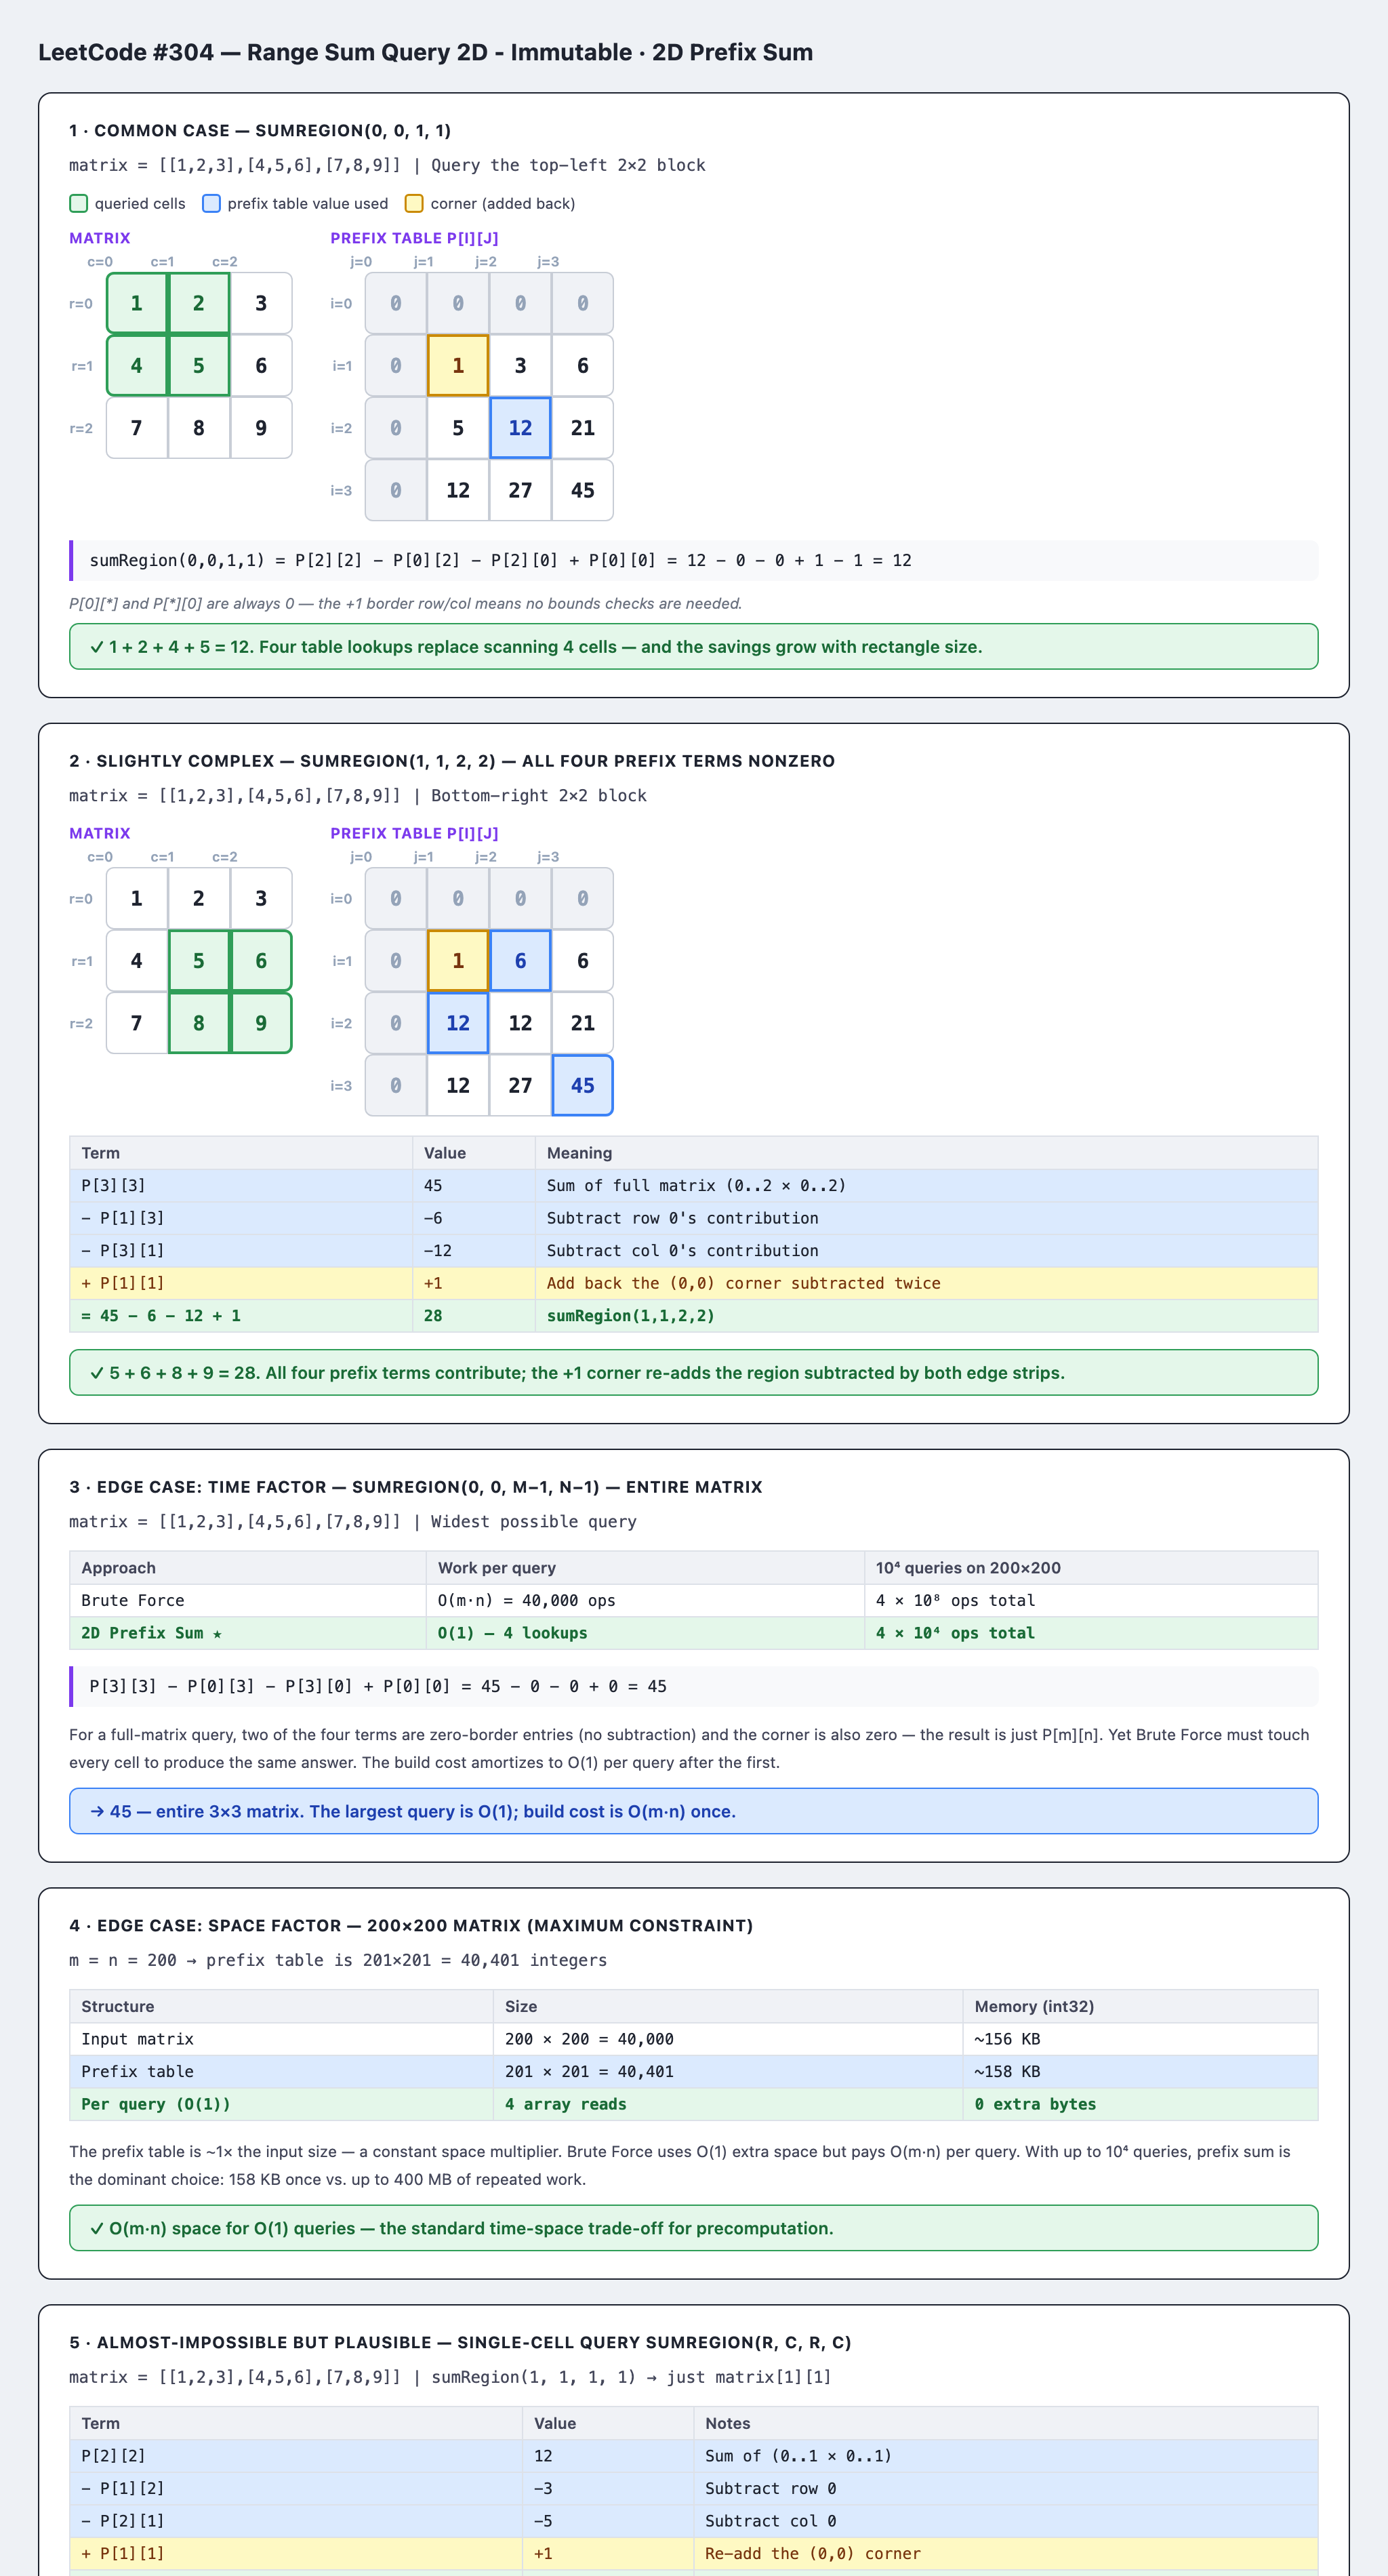